# CUSTOMER SEGMENTATION & CUSTOMER LIFETIME VALUE (CLV) ANALYSIS

### BUSINESS SCENARIO AND PROBLEM

A UK-based online retail company sells unique all-occasion gifts, primarily to wholesale customers across multiple countries. The company has accumulated over 500,000 transactions spanning a full year but currently treats all customers identically — same marketing campaigns, same communication frequency, same discount offers.

This one-size-fits-all approach is inefficient. High-value loyal customers receive the same attention as customers who bought once and never returned. Marketing budget is being wasted on the wrong segments while the most valuable customers aren't being rewarded or retained effectively.

The company needs a data-driven customer segmentation strategy to understand who their customers actually are, what each group is worth, and how to engage each segment differently to maximize revenue and retention.


QUESTIONS FROM STAKEHOLDERS

1. Who are our most valuable customers and what percentage of revenue do they drive?
2. How many customers are at risk of churning — and what is the revenue at stake?
3. What is the estimated lifetime value of each customer segment?
4. Which customer segments should we prioritize for marketing investment?
5. What specific retention or growth strategy should we apply to each segment?

# PLAN STAGE

IMPORTS AND DATASET UPLOAD

In [1]:
# import the necessary libraries and modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# load the dataset

df = pd.read_csv('online_retail.csv')

DATA EXPLORATION

In [3]:
# check the dataset

df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.00,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.00,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.00,United Kingdom


In [4]:
# check the shape of the dataset

df.shape

(541909, 8)

In [5]:
# check the data types of the columns

df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [6]:
# assess the basic info of dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
# gather basic statistics of the dataset

df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


In [8]:
# check for empty values in the dataset

df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# check for duplicated values in the dataset

df.duplicated().sum()

np.int64(5268)

In [10]:
# count cancelled invoices

df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0]

9288

In [11]:
# count negative quantity rows

df[df['Quantity'] < 0].shape[0]

10624

DATA CLEANING AND TRANSFORMATION

In [12]:
# remove rows with missing CustomerID

df1 = df.dropna(subset=['CustomerID'])
df1.shape

(406829, 8)

In [13]:
# standardize the column names

df1.rename(columns={'InvoiceNo': 'invoice_no', 'StockCode': 'stock_code', 'Description': 'description',
                    'Quantity': 'quantity', 'InvoiceDate': 'invoice_date', 'UnitPrice': 'unit_price',
                    'CustomerID': 'customer_id', 'Country': 'country'}, inplace=True)
df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


In [14]:
# convert customer_id to integer

df1['customer_id'] = df1['customer_id'].astype(int)
df1.dtypes

invoice_no          str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
customer_id       int64
country             str
dtype: object

In [15]:
# Convert invoice_date to datetime

df1['invoice_date'] = pd.to_datetime(df1['invoice_date'])
df1.dtypes

invoice_no                 str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id              int64
country                    str
dtype: object

In [16]:
# remove cancelled invoices and check the count of cancelled invoices again

df1 = df1[~df1['invoice_no'].astype(str).str.startswith('C')]
df1[df1['invoice_no'].astype(str).str.startswith('C')].shape[0]

0

In [17]:
# remove negative and zero quantities and check if anything is still left

df1 = df1[df1['quantity'] > 0]
df1[df1['quantity'] <= 0].shape[0]

0

In [18]:
# remove zero and negative unit prices and check if anything is still left

df1 = df1[df1['unit_price'] > 0]
df1[df1['unit_price'] <= 0].shape[0]

0

In [19]:
# remove the duplicated rows and check if there are any duplicates left

df1 = df1.drop_duplicates(keep='first')
df1.duplicated().sum()

np.int64(0)

In [20]:
# new column 'total_price' by multiplying 'quantity' and 'unit_price'

df1['total_price'] = df1['quantity'] * df1['unit_price']
df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [21]:
# set snapshot date for recency calculation

snapshot_date = df1['invoice_date'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [22]:
# verify the cleaned dataset's statistics 

df1.describe()

,quantity,invoice_date,unit_price,customer_id,total_price
count,392692.00,392692,392692.00,392692.00,392692.00
mean,13.12,2011-07-10 19:13:07.771892,3.13,15287.84,22.63
min,1.00,2010-12-01 08:26:00,0.00,12346.00,0.00
25%,2.00,2011-04-07 11:12:00,1.25,13955.00,4.95
50%,6.00,2011-07-31 12:02:00,1.95,15150.00,12.45
75%,12.00,2011-10-20 12:53:00,3.75,16791.00,19.80
max,80995.00,2011-12-09 12:50:00,8142.75,18287.00,168469.60
std,180.49,NaN,22.24,1713.54,311.10


In [23]:
# check the number of unique customers in the dataset after data cleaning

df1['customer_id'].nunique()

4338

### PLAN STAGE SUMMARY

- Loaded the raw Online Retail dataset containing 541,909 transactions across 8 columns spanning December 2010 to December 2011
- Identified 135,080 missing CustomerID values representing 24.9% of the dataset — dropped as these transactions cannot be linked to any customer identity and are unusable for RFM analysis
- Identified and removed 9,288 cancelled invoices prefixed with 'C' representing product returns and reversals
- Removed 10,624 negative quantity rows representing unlogged returns not captured as formal cancellations
- Removed 5,268 fully duplicate records where every column value was identical, indicating likely system logging errors
- Standardized all column names to snake_case for consistency and readability
- Converted `invoice_date` from string to datetime format to enable time-based calculations
- Converted `customer_id` from float to integer as it is a discrete identifier with no decimal meaning
- Created `total_price` column as `quantity × unit_price` — the core revenue metric for all downstream analysis
- Set snapshot date to 2011-12-10 as the reference point for recency calculation
- Extreme values in `quantity` and `total_price` were retained as they represent legitimate bulk purchases — their influence will be managed through log transformation in the RFM engineering stage
- Final clean dataset contains 392,692 transactions across 4,338 unique customers — ready for RFM feature engineering

# ANALYZE STAGE

### RFM FEATURE ENGINEERING

In [24]:
# aggregate transactions into one row per customer to calculate RFM metrics

rfm = df1.groupby('customer_id').agg(
    recency   = ('invoice_date', lambda x: (snapshot_date - x.max()).days),
    frequency = ('invoice_no', 'nunique'),
    monetary  = ('total_price', 'sum')
).reset_index()

rfm.describe()

,customer_id,recency,frequency,monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2048.69
std,1721.81,100.01,7.70,8985.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,306.48
50%,15299.50,51.00,2.00,668.57
75%,16778.75,142.00,5.00,1660.60
max,18287.00,374.00,209.00,280206.02


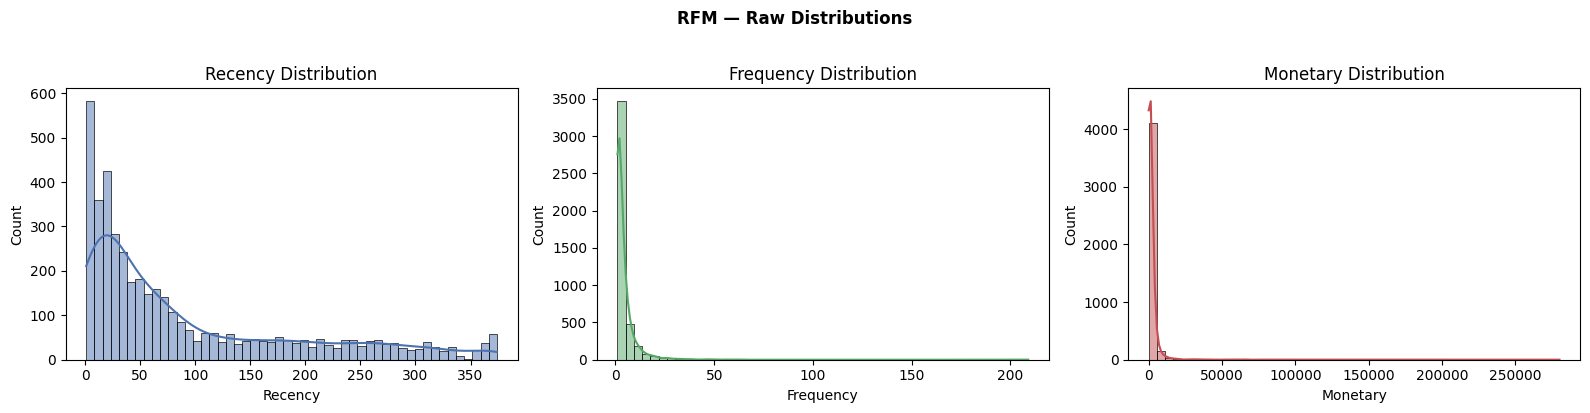

In [25]:
# visualize raw distributions before transformation

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes, ['recency', 'frequency', 'monetary'],['#4C72B0', '#55A868', '#C44E52']):
    sns.histplot(rfm[col], bins=50, ax=ax, color=color, kde=True)
    ax.set_title(f'{col.capitalize()} Distribution')
    ax.set_xlabel(col.capitalize())

plt.suptitle('RFM — Raw Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# check the skewness of raw features

rfm[['recency', 'frequency', 'monetary']].skew()

recency      1.25
frequency   12.07
monetary    19.34
dtype: float64

OBSERVATION:

Recency is moderately skewed (1.25) with most customers active within the last 50 days, though a visible tail toward 374 days indicates a dormant segment that never returned after their first purchase. Frequency and Monetary are severely skewed at 12.07 and 19.34 respectively — nearly the entire customer base is compressed into the first bar, making any variation invisible at raw scale.

LOG TRANSFORMATION

In [27]:
# use log1p transform on frequency and monetary to compress right skew

rfm['frequency_log'] = np.log1p(rfm['frequency'])
rfm['monetary_log']  = np.log1p(rfm['monetary'])

In [28]:
# check for skewness after transformation
rfm[['frequency_log', 'monetary_log']].skew()

frequency_log   1.21
monetary_log    0.40
dtype: float64

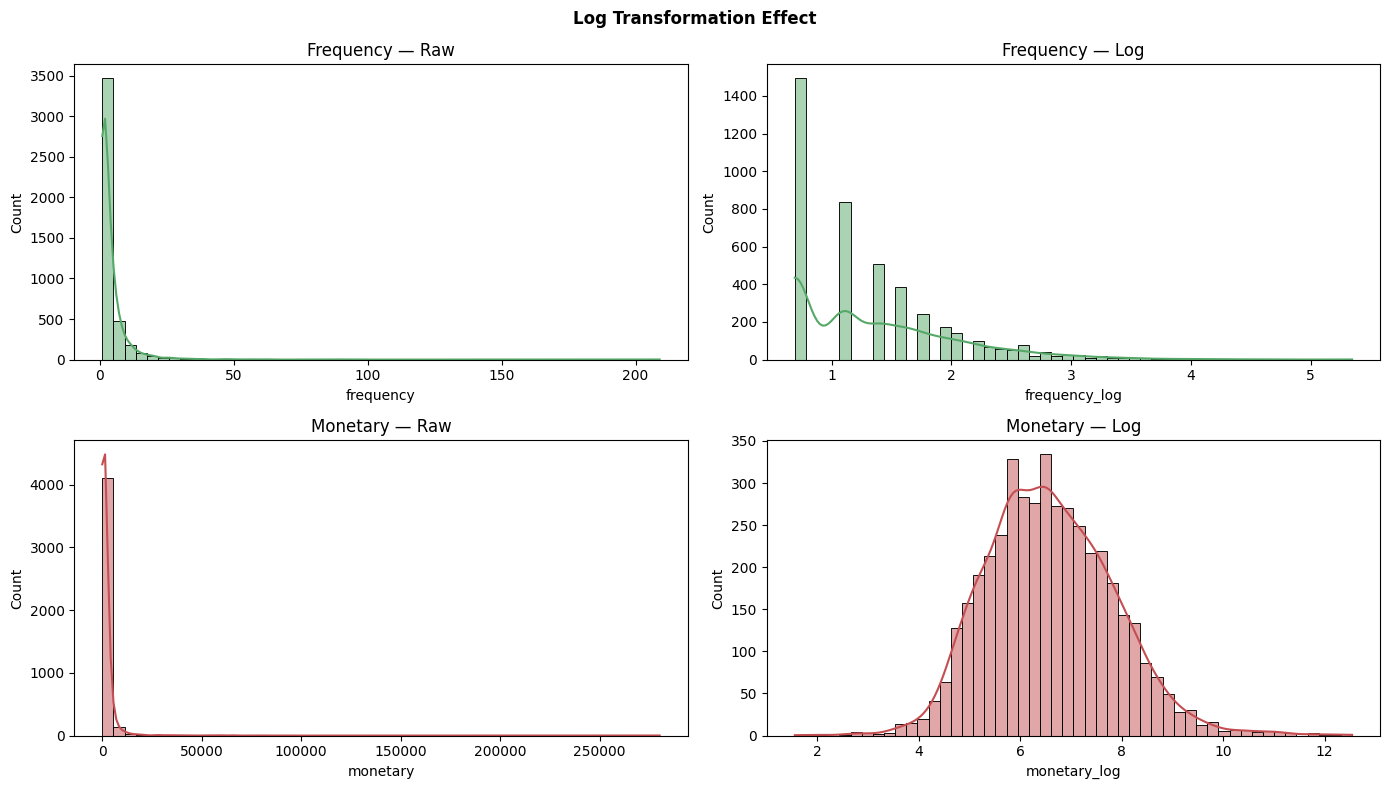

In [29]:
# before vs after visual comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

pairs = [
    ('frequency',     'Frequency — Raw', axes[0][0], '#55A868'),
    ('frequency_log', 'Frequency — Log', axes[0][1], '#55A868'),
    ('monetary',      'Monetary — Raw',  axes[1][0], '#C44E52'),
    ('monetary_log',  'Monetary — Log',  axes[1][1], '#C44E52'),
]

for col, title, ax, color in pairs:
    sns.histplot(rfm[col], bins=50, ax=ax, color=color, kde=True)
    ax.set_title(title)

plt.suptitle('Log Transformation Effect', fontweight='bold')
plt.tight_layout()
plt.show()

OBSERVATION:

Log transformation brought Frequency down to 1.21 and Monetary to 0.40, with Monetary now forming a near-normal curve centred around £400 in raw spend. The remaining left-side concentration in Frequency is not a data issue — it reflects the genuine reality that one-time buyers structurally dominate this customer base.

RFM SCORING

In [30]:
# make quintile scoring 1–5 across all three dimensions

rfm['r_score'] = pd.qcut(rfm['recency'],                        q=5, labels=[5, 4, 3, 2, 1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['m_score'] = pd.qcut(rfm['monetary'],                       q=5, labels=[1, 2, 3, 4, 5])

rfm[['r_score', 'f_score', 'm_score']] = rfm[['r_score', 'f_score', 'm_score']].astype(int)

In [31]:
# get the composite RFM score

rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

rfm.head(10)

,customer_id,recency,frequency,monetary,frequency_log,monetary_log,r_score,f_score,m_score,rfm_score
0,12346,326,1,77183.60,0.69,11.25,1,1,5,7
1,12347,2,7,4310.00,2.08,8.37,5,5,5,15
2,12348,75,4,1797.24,1.61,7.49,2,4,4,10
3,12349,19,1,1757.55,0.69,7.47,4,1,4,9
4,12350,310,1,334.40,0.69,5.82,1,1,2,4
5,12352,36,8,2506.04,2.20,7.83,3,5,5,13
6,12353,204,1,89.00,0.69,4.50,1,1,1,3
7,12354,232,1,1079.40,0.69,6.99,1,1,4,6
8,12355,214,1,459.40,0.69,6.13,1,1,2,4
9,12356,23,3,2811.43,1.39,7.94,4,3,5,12


FEATURE SCALING

In [32]:
# applied standard scaler on recency + log-transformed F and M for clustering input

scaler     = StandardScaler()
rfm_array  = scaler.fit_transform(rfm[['recency', 'frequency_log', 'monetary_log']])

rfm_scaled = pd.DataFrame(rfm_array, columns=['recency_scaled', 'frequency_scaled', 'monetary_scaled'])
rfm_scaled['customer_id'] = rfm['customer_id'].values

rfm_scaled.head()

,recency_scaled,frequency_scaled,monetary_scaled,customer_id
0,2.33,-0.96,3.71,12346
1,-0.91,1.07,1.41,12347
2,-0.18,0.39,0.72,12348
3,-0.74,-0.96,0.70,12349
4,2.17,-0.96,-0.61,12350


### EXPLORATORY DATA ANALYSIS (EDA)

REVENUE CONCENTRATION

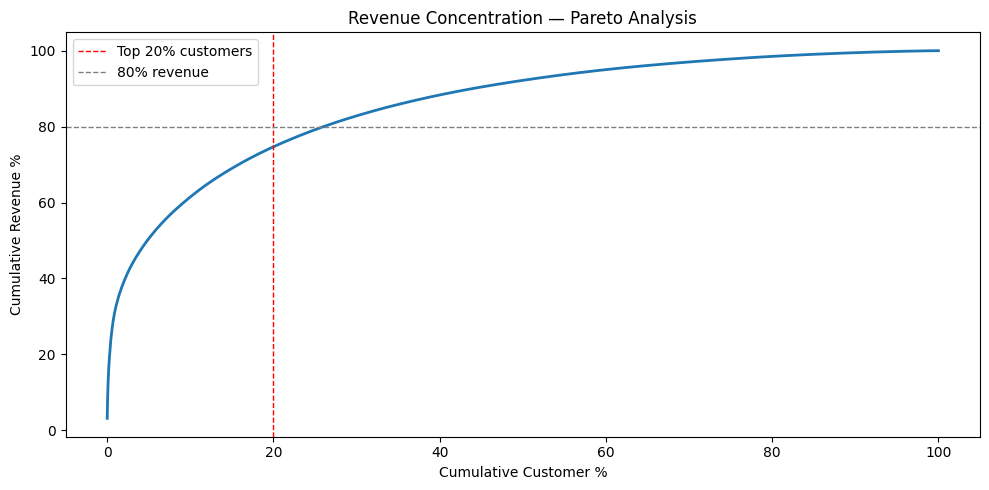

In [33]:
# pareto analysis — cumulative revenue contribution by customer

rfm_sorted = rfm.sort_values('monetary', ascending=False).reset_index(drop=True)
rfm_sorted['cumulative_revenue_pct'] = rfm_sorted['monetary'].cumsum() / rfm_sorted['monetary'].sum() * 100
rfm_sorted['customer_pct'] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rfm_sorted['customer_pct'], rfm_sorted['cumulative_revenue_pct'], linewidth=2)
ax.axvline(x=20, color='red', linestyle='--', linewidth=1, label='Top 20% customers')
ax.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='80% revenue')
ax.set_xlabel('Cumulative Customer %')
ax.set_ylabel('Cumulative Revenue %')
ax.set_title('Revenue Concentration — Pareto Analysis')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
# exact revenue share of top 20% customers

top_20_pct  = int(len(rfm_sorted) * 0.20)
top_20_revenue = rfm_sorted.head(top_20_pct)['monetary'].sum()
total_revenue  = rfm_sorted['monetary'].sum()

round((top_20_revenue / total_revenue) * 100, 2)

np.float64(74.66)

INSIGHTS

- The top 20% of customers drive 74.66% of total revenue, confirming that revenue is heavily concentrated in a small customer minority — the remaining 80% of customers collectively contribute just 25%.

- The curve rises steeply before the 20% mark and flattens sharply after, making the imbalance visually clear.

PURCHASE FREQUENCY DISTRIBUTION

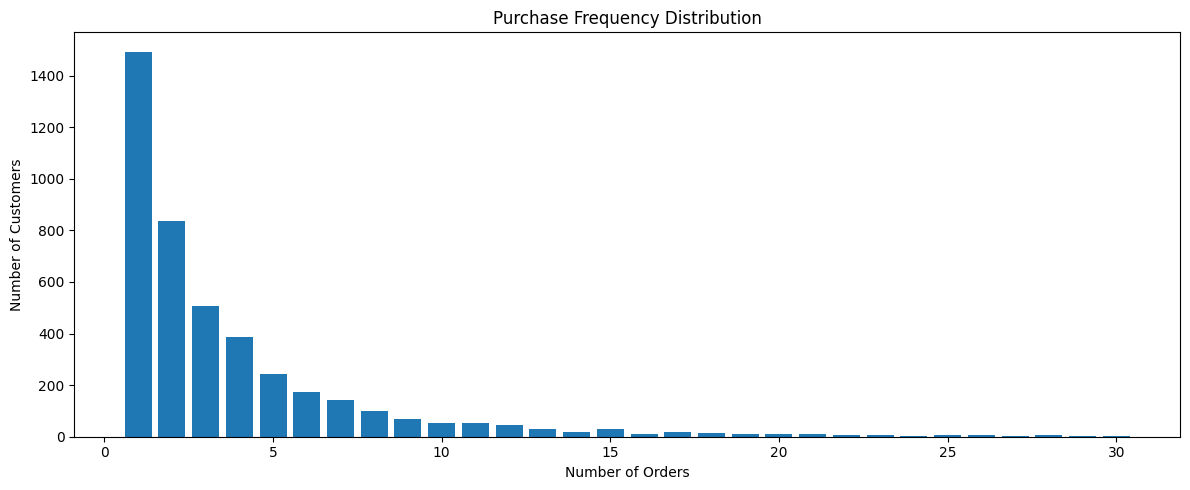

In [35]:
# how many customers bought only once, twice, etc.

freq_dist = rfm['frequency'].value_counts().sort_index()
one_time  = rfm[rfm['frequency'] == 1].shape[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(freq_dist.index[:30], freq_dist.values[:30])
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.set_title('Purchase Frequency Distribution')
plt.tight_layout()
plt.show()

In [36]:
# one-time buyer percentage

round(one_time / len(rfm) * 100, 2)

34.42

INSIGHTS

- 34.42% of customers placed only a single order, making one-time buyers the single largest group in the dataset. The first bar visually dominates every other frequency band.

- Purchase activity drops sharply after order 2 and becomes negligible beyond order 10, confirming that most customers never develop a repeat buying habit.

CUSTOMER INACTIVITY ANALYSIS

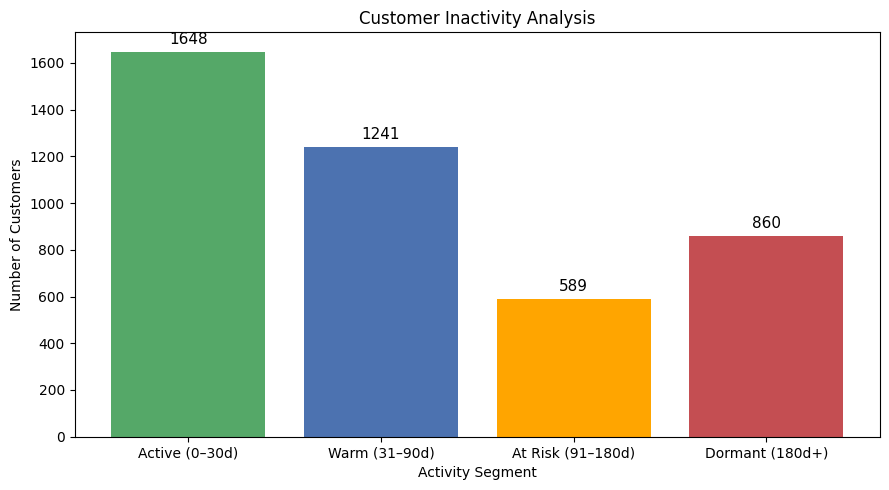

In [37]:
# bucket customers by recency into activity bands

bins   = [0, 30, 90, 180, rfm['recency'].max() + 1]
labels = ['Active (0–30d)', 'Warm (31–90d)', 'At Risk (91–180d)', 'Dormant (180d+)']

rfm['activity_segment'] = pd.cut(rfm['recency'], bins=bins, labels=labels, right=True)

activity_counts = rfm['activity_segment'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(activity_counts.index, activity_counts.values, color=['#55A868', '#4C72B0', '#FFA500', '#C44E52'])

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Activity Segment')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Inactivity Analysis')
plt.tight_layout()
plt.show()

In [38]:
# revenue at stake from dormant customers

dormant_revenue = rfm[rfm['activity_segment'] == 'Dormant (180d+)']['monetary'].sum()
round((dormant_revenue / total_revenue) * 100, 2)

np.float64(6.24)

INSIGHTS

- The active segment (0–30d) is the largest at ~1,640 customers, indicating a reasonably healthy recent buyer base. However the At Risk and Dormant groups combined account for roughly 1,450 customers — over a third of the total base.

- Dormant customers (180d+) number ~860 but contribute only 6.24% of total revenue, suggesting they were predominantly low-value buyers before going inactive.

MONTHLY REVENUE TREND

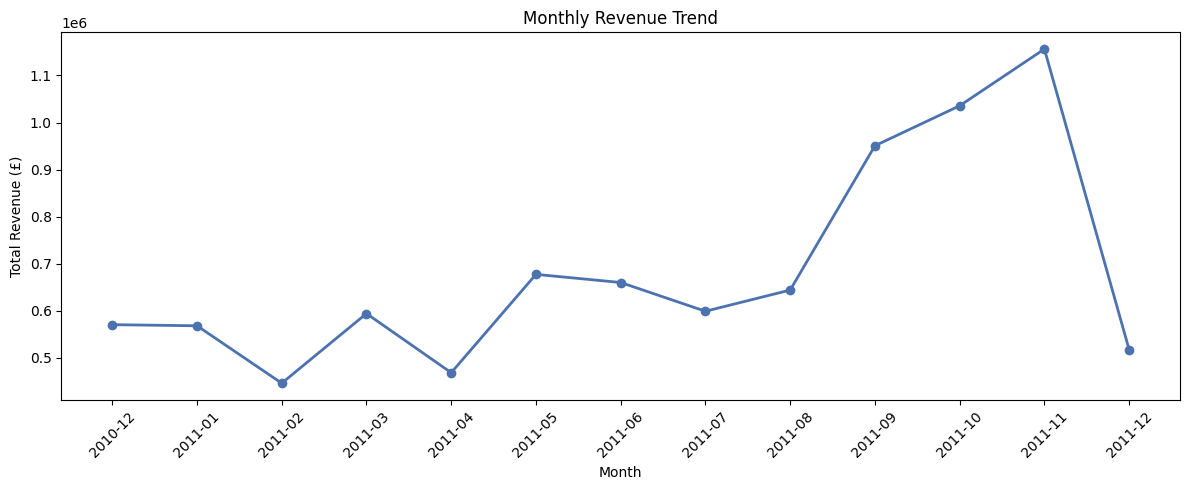

In [39]:
# aggregate revenue by month across the dataset period

df1['month'] = df1['invoice_date'].dt.to_period('M')
monthly_revenue = df1.groupby('month')['total_price'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue.index.astype(str), monthly_revenue.values, color='#4C72B0', linewidth=2, marker='o')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (£)')
ax.set_title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

INSIGHTS

- Revenue stays relatively flat between £570K–£670K from Dec 2010 through mid-2011, with two visible dips in Feb and Apr 2011. A strong upward trend begins from September 2011, peaking at £1.14M in November 2011 — nearly double the early-year average.

- The sharp drop in December 2011 is expected and not a cause for concern — the dataset only captures the first 10 days of that month, so the number is naturally incomplete compared to every other full month.

RFM SCATTER PATTERNS

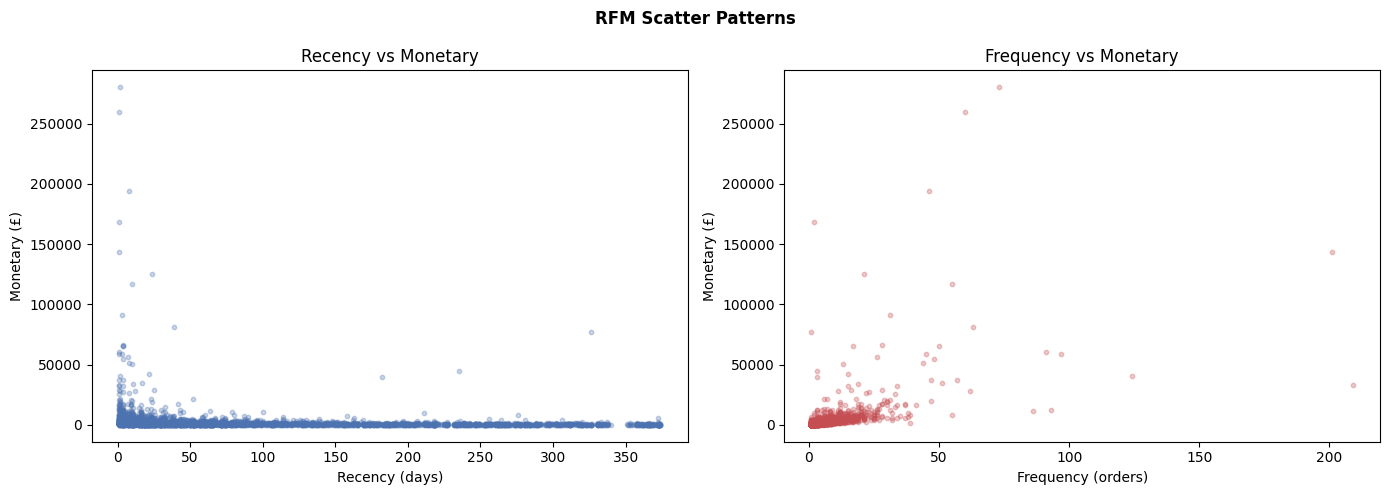

In [40]:
# scatter plots to visually confirm natural customer groupings before clustering

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rfm['recency'], rfm['monetary'], alpha=0.3, color='#4C72B0', s=10)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary')

axes[1].scatter(rfm['frequency'], rfm['monetary'], alpha=0.3, color='#C44E52', s=10)
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary')

plt.suptitle('RFM Scatter Patterns', fontweight='bold')
plt.tight_layout()
plt.show()

INSIGHTS

- In the Recency vs Monetary plot, high-spending customers are almost entirely concentrated in the 0–50 day recency range, meaning recent buyers also tend to be the bigger spenders. Beyond 50 days, spend drops to near zero with very few exceptions.

- The Frequency vs Monetary plot shows a similar pattern — the bulk of customers cluster at low frequency and low spend in the bottom-left corner, with a small number of high-frequency, high-spend outliers scattered above. Both plots confirm that natural groupings exist in the data, validating that K-Means will find meaningful structure.

### ANALYSE STAGE SUMMARY

RFM FEATURE ENGINEERING
- Aggregated 392,692 transactions into 4,338 customer-level RFM profiles. The median customer purchased 51 days ago, placed 2 unique orders, and spent £668 — revealing that the typical customer is relatively recent but low in engagement and spend.
- Frequency and Monetary were severely right-skewed (12.07 and 19.34) driven by a small number of extreme buyers, while Recency showed moderate skew (1.25). 
- Log1p transformation was applied to Frequency and Monetary, reducing skewness to 1.21 and 0.40 respectively and making the distributions suitable for clustering.
- Each RFM dimension was scored 1–5 using quintile binning, with Recency reverse-scored so that Score 5 always means better. StandardScaler was applied to the three features and saved as a separate dataframe to keep business-readable outputs clean from model inputs.

EXPLORATORY DATA ANALYSIS
- The top 20% of customers drive 74.66% of total revenue, confirming heavy revenue concentration in a small minority. 34.42% of the customer base placed only a single order, making one-time buyers the largest and highest churn-risk group in the dataset.
- Activity segmentation shows 1,648 active customers (0–30d) against 860 dormant (180d+) and 589 at risk (91–180d) — meaning roughly 33% of the base has not purchased in over 3 months. Dormant customers contribute only 6.24% of revenue despite their size.
- Monthly revenue trended upward through the second half of 2011, peaking at £1.14M in November before dropping in December due to partial month data. 
- RFM scatter plots confirmed that high-spending customers cluster tightly in the low-recency, high-frequency zone — validating that meaningful customer groupings exist ahead of clustering.

# CONSTRUCT STAGE

In [41]:
# Run KMeans across K = 2 to 10, record inertia and silhouette scores

k_range = range(2, 11)
inertia_values = []
silhouette_values = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(rfm_scaled, labels))

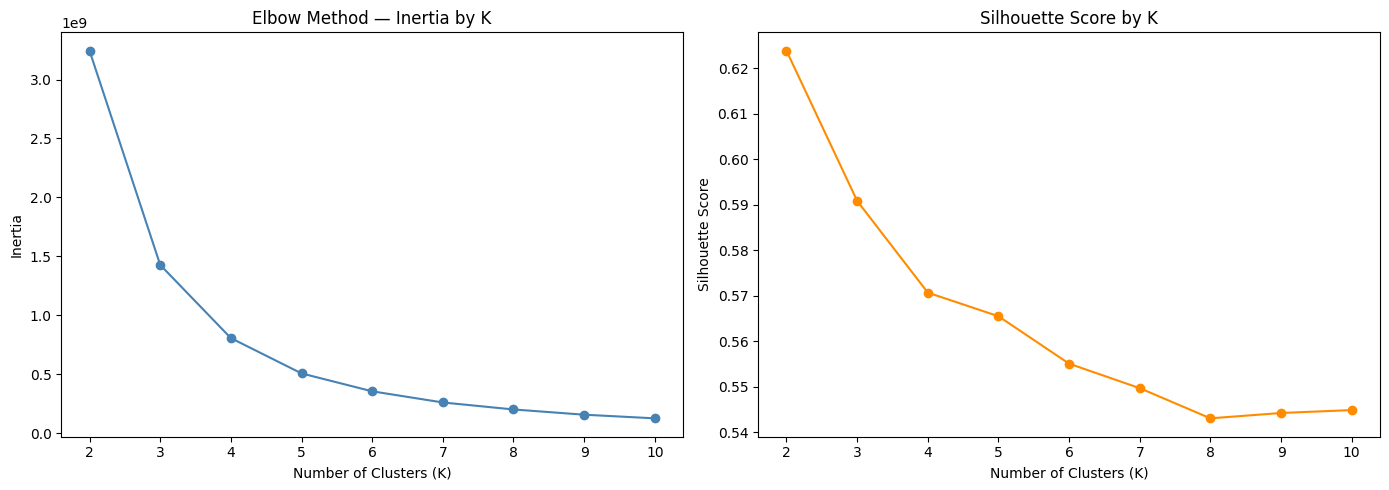

In [42]:
# Plot elbow curve and silhouette scores side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_values, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia by K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_values, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

OBSERVATIONS:
- The elbow curve drops sharply from K=2 (3.2B) to K=4 (0.8B), then flattens significantly — the bend is clearest between K=4 and K=5, suggesting 4 or 5 as the natural elbow
- Silhouette score declines consistently from K=2 (0.63) with no recovery peak — meaning mathematically K=2 gives the cleanest separation, but that's too coarse for business use; K=4 (0.57) holds a reasonable score before the steeper drop

In [43]:
# Fit KMeans with index-aligned scaled data and profile clusters

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm[['recency', 'frequency_log', 'monetary_log']]),
    columns=['recency_scaled', 'frequency_scaled', 'monetary_scaled'],
    index=rfm.index
)

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

cluster_profile_scores = rfm.groupby('cluster').agg(
    recency_mean=('recency', 'mean'),
    frequency_mean=('frequency', 'mean'),
    monetary_mean=('monetary', 'mean'),
    r_score=('r_score', 'mean'),
    f_score=('f_score', 'mean'),
    m_score=('m_score', 'mean'),
    rfm_score=('rfm_score', 'mean'),
    customer_count=('recency', 'count')
).round(2)

cluster_profile_scores

,recency_mean,frequency_mean,monetary_mean,r_score,f_score,m_score,rfm_score,customer_count
cluster,,,,,,,,
0,58.04,1.51,384.22,3.17,2.05,1.97,7.19,1377
1,259.41,1.37,385.39,1.11,1.84,1.87,4.82,938
2,19.77,15.84,9823.43,4.40,4.98,4.95,14.33,571
3,46.06,4.21,1644.26,3.55,3.87,3.94,11.37,1452


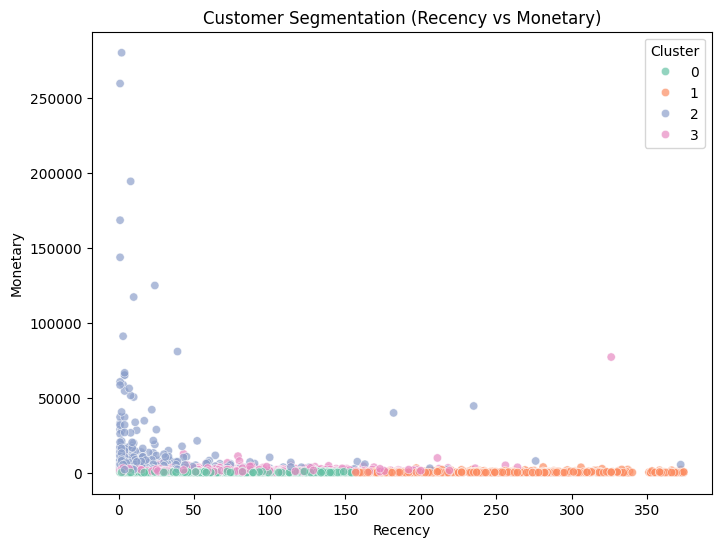

In [44]:
# visualize clusters in recency vs monetary space

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='recency',
    y='monetary',
    hue='cluster',
    palette='Set2',
    alpha=0.7
)

plt.title('Customer Segmentation (Recency vs Monetary)')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.show()

RECENCY vs MONETARY:
- High-monetary customers are heavily concentrated at low recency, showing that recent engagement strongly aligns with higher spending behavior.
- As recency increases, customers rapidly shift toward low monetary contribution, forming a dense inactive/low-value segment with potential churn risk.

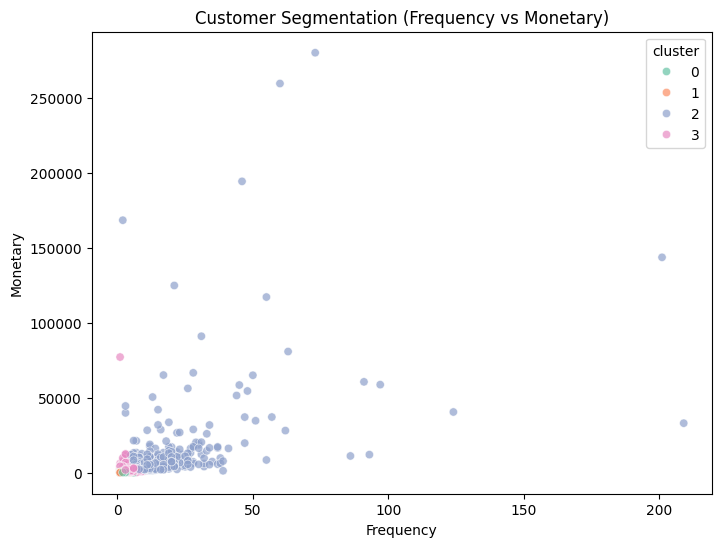

In [45]:
# visualize clusters in recency vs monetary space

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='frequency',
    y='monetary',
    hue='cluster',
    palette='Set2',
    alpha=0.7
)

plt.title('Customer Segmentation (Frequency vs Monetary)')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

FREQUENCY vs MONETARY:
- Majority of customers are concentrated in the low-frequency, low-monetary zone, indicating a large base of low-value users contributing minimally to revenue.
- A distinct cluster of high-frequency, high-monetary customers stands out, representing the key revenue-driving segment with disproportionate value contribution.

In [46]:
# Map cluster numbers to segment names

segment_map = {
    2: 'Champions',
    3: 'Loyal Customers',
    0: 'Potential Loyalists',
    1: 'At Risk'
}

rfm['segment'] = rfm['cluster'].map(segment_map)
rfm['segment'].value_counts()

segment
Loyal Customers        1452
Potential Loyalists    1377
At Risk                 938
Champions               571
Name: count, dtype: int64

In [47]:
# Revenue contribution by segment

segment_revenue = rfm.groupby('segment')['monetary'].sum()
segment_revenue_pct = (segment_revenue / segment_revenue.sum() * 100).round(2)
pd.DataFrame({'total_revenue': segment_revenue.round(2), 'revenue_pct': segment_revenue_pct})

,total_revenue,revenue_pct
segment,,
At Risk,361494.46,4.07
Champions,5609180.83,63.12
Loyal Customers,2387468.10,26.86
Potential Loyalists,529065.50,5.95


OBSERVATIONS:
- Champions are just 571 customers (13% of base) but drive 63.12% of total revenue — the most critical segment to retain by far
- At Risk and Potential Loyalists together hold 2,315 customers but contribute only 10% of revenue combined, signalling low engagement that needs addressing

In [48]:
# Customer Lifetime Value (CLV) proxy — annualised spend estimate per segment

clv_proxy = rfm.groupby('segment').agg(
    avg_order_value=('monetary', lambda x: (x / rfm.loc[x.index, 'frequency']).mean()),
    avg_frequency=('frequency', 'mean'),
    customer_count=('monetary', 'count')
).round(2)

clv_proxy['clv_proxy'] = (clv_proxy['avg_order_value'] * clv_proxy['avg_frequency'] * 12).round(2)
clv_proxy

,avg_order_value,avg_frequency,customer_count,clv_proxy
segment,,,,
At Risk,295.09,1.37,938,4851.28
Champions,731.64,15.84,571,139070.13
Loyal Customers,498.54,4.21,1452,25186.24
Potential Loyalists,285.63,1.51,1377,5175.62


OBSERVATIONS:
- Champions have an annualised CLV proxy of £139,070 — roughly 5.5x that of Loyal Customers (£25,186) and 28x that of At Risk customers (£4,851)
- Potential Loyalists have a CLV proxy of just £5,175 despite being 1,377 customers — low order frequency (1.51) is the primary drag on their value

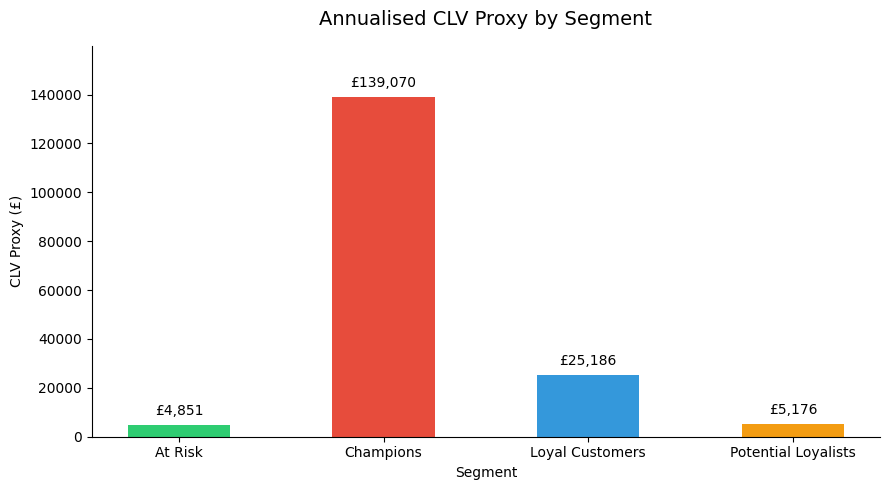

In [49]:
# CLV proxy by segment — bar chart

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
segments = clv_proxy.index.tolist()
values = clv_proxy['clv_proxy'].tolist()

bars = ax.bar(segments, values, color=colors, edgecolor='none', width=0.5)

ax.set_title('Annualised CLV Proxy by Segment', fontsize=14, pad=15)
ax.set_xlabel('Segment')
ax.set_ylabel('CLV Proxy (£)')
ax.bar_label(bars, fmt='£{:,.0f}', padding=5, fontsize=10)
ax.set_ylim(0, max(values) * 1.15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### CONSTRUCT STAGE SUMMARY

- Elbow method and silhouette scoring tested K=2 to K=10; K=4 selected based on elbow bend and silhouette score of 0.57
- KMeans fitted on rfm_scaled with customer_id as index; cluster labels and segment names mapped back to rfm dataframe
- Four segments identified: Champions (571), Loyal Customers (1452), Potential Loyalists (1377), At Risk (938)
- Champions drive 63.12% of total revenue despite being only 13% of the customer base
- Annualised CLV proxy confirms Champions (£139,070) are worth 5.5x Loyal Customers (£25,186) and 28x At Risk (£4,851)
- rfm dataframe now contains cluster, segment, and CLV proxy — ready for Execute stage

# EXECUTE STAGE

### CONCLUSION

This project applied the PACE framework to segment 4,338 customers of a UK-based e-commerce business using RFM analysis and K-Means clustering across 392,692 transactions spanning December 2010 to December 2011.

Four behaviorally distinct segments were identified — Champions, Loyal Customers, Potential Loyalists, and At Risk. The clustering confirmed what the EDA had signalled early: this business has an extreme revenue concentration problem. A small group of high-frequency, high-spend customers is carrying the entire revenue base, while the majority of customers remain under-engaged after their first purchase.

The CLV proxy quantifies the stakes — Champions are worth 5.5x Loyal Customers and 28x At Risk customers on an annualised basis. Every strategic decision this business makes about marketing spend, retention investment, and channel prioritisation should flow from that number.

The recommendations that follow are not generic marketing advice — they are a direct translation of what the data found into actions the business can take, segment by segment.

### STRATEGIC RECOMMENDATIONS

The segmentation reveals a highly concentrated revenue structure — 571 Champions generate 63% of total revenue while 2,315 customers across the bottom two segments contribute less than 11% combined. The following recommendations are a direct response to what the data is saying.

---

### 1. Protect the Champion Base at All Costs

**Segment Identified:** Champions — 571 customers, 63.12% revenue, CLV £139,070, avg recency 20 days, avg 15.8 orders

These customers are transacting almost every three weeks and spending nearly £10K on average. They are not occasional buyers — they are the business. Despite representing only 13% of the customer base, losing even a small portion of this segment would have an outsized revenue impact that no other segment can compensate for.

Recommended Steps:
- Build a VIP retention programme exclusively for this segment — early product access, dedicated account support, or loyalty rewards tied to order frequency rather than spend thresholds
- Monitor recency closely — any Champion crossing 45+ days without a purchase should trigger a personalised re-engagement touchpoint immediately, before they drift into Loyal Customer territory
- Never expose this segment to generic mass promotions — discounting to customers already paying full price at high frequency erodes margin without adding value

---

### 2. Convert Loyal Customers Into Champions

**Segment Identified:** Loyal Customers — 1,452 customers, 26.86% revenue, CLV £25,186, avg 4.2 orders, avg recency 46 days

This is the most strategically important growth segment. They are recent, they spend meaningfully, and they already have an established purchase habit. The gap between their CLV (£25,186) and Champions (£139,070) is driven almost entirely by order frequency — 4.2 vs 15.8. The product and trust are already there.

Recommended Steps:
- Run frequency-focused campaigns for this segment specifically — bundle offers, subscription options, or repeat-purchase incentives that reward ordering more often rather than spending more per order
- Identify the top 20% of Loyal Customers by monetary value and treat them as Champion candidates — give them early access to new products or exclusive offers to accelerate the transition
- Set an internal benchmark: if avg frequency for this segment moves from 4.2 to 6+ orders, the revenue impact at current AOV would be significant enough to measure as a campaign KPI

---

### 3. Activate Potential Loyalists Before They Go Cold

**Segment Identified:** Potential Loyalists — 1,377 customers, 5.95% revenue, CLV £5,176, avg 1.51 orders, avg recency 58 days

These customers have purchased recently but almost all of them only once. They are in the decision window — engaged enough to buy, but not yet committed enough to return. At 58 days average recency they are still warm, but that window closes fast. Low frequency is the only thing separating them from Loyal Customers.

Recommended Steps:
- Deploy a second-purchase campaign targeting this segment within 30 days of their first order — the probability of a customer returning drops sharply after 60 days of inactivity
- Use product affinity from their first order to personalise the follow-up — a relevant recommendation is significantly more effective than a generic discount at this stage
- Track 90-day conversion rate from first to second purchase as the primary KPI for this segment — if that number moves, CLV for this group moves with it

---

### 4. Run a Selective Win-Back for At Risk Customers

**Segment Identified:** At Risk — 938 customers, 4.07% revenue, CLV £4,851, avg recency 259 days, avg 1.37 orders

At 259 days average recency these customers have been absent for over eight months. Most have likely already shifted spend to a competitor. Their CLV of £4,851 is the lowest across all segments, meaning the revenue upside from recovery is limited. A blanket win-back effort across all 938 would be resource-inefficient.

Recommended Steps:
- Segment this group further by monetary value before investing in win-back — focus only on At Risk customers who previously had monetary values above the dataset median of £668, as they represent the recoverable revenue worth pursuing
- Send a single high-incentive re-engagement campaign with a clear expiry window to create urgency — if there is no response, deprioritise further outreach entirely
- Use this segment as a churn signal for the broader business — 938 customers averaging 259 days inactive is a pattern, not a coincidence, and the root cause likely sits in post-purchase experience or product-market fit for certain categories

---

### 5. Address the Single-Order Customer Problem Structurally

**Pattern Identified:** 34.42% of customers — roughly 1 in 3 — placed only one order across the entire 12-month period. This is not a segmentation issue, it is a structural acquisition vs retention imbalance. The business is bringing customers in but failing to convert first purchases into relationships.

Recommended Steps:
- Introduce a post-purchase onboarding sequence for all new customers — a 3-email flow at day 3, day 10, and day 25 after first purchase focused on product education and social proof rather than discounting
- Measure and report first-to-second purchase conversion rate as a top-level business KPI alongside revenue — it is currently invisible in the reporting and that is why it has not been addressed
- Audit the first purchase experience end to end — delivery time, packaging, product accuracy — since single-order drop-off at this scale typically points to an experience failure rather than a demand failure

---

### 6. Reduce Dangerous Revenue Concentration

**Pattern Identified:** The top 20% of customers drive 74.66% of total revenue. Champions alone — 13% of the base — drive 63.12%. This level of concentration means the business is one bad retention quarter away from a significant revenue problem. There is no diversification buffer.

Recommended Steps:
- Set a strategic goal to reduce Champion revenue dependency from 63% to below 50% over 12 months — not by losing Champions, but by accelerating Loyal Customer CLV growth
- Report revenue concentration as a risk metric in business reviews — if the Champion segment shrinks by even 10%, the revenue impact is larger than the entire At Risk and Potential Loyalist segments combined
- Build the Loyal Customer segment deliberately as the revenue buffer — their 1,452 customers at higher frequency would meaningfully reduce concentration risk while growing total revenue

---

### 7. Build a Q4 Dependency Mitigation Strategy

**Pattern Identified:** Monthly revenue peaked at £1.14M in November 2011 with a sharp drop in December due to partial data. The broader trend shows the business is heavily Q4 dependent — a common pattern in UK e-commerce gifting categories but a structural vulnerability if left unmanaged.

Recommended Steps:
- Identify which product categories drive the Q4 spike and assess whether any have year-round demand potential — if yes, run targeted campaigns for those categories in Q1 and Q2 to smooth the revenue curve
- Use the Champion and Loyal Customer segments as the test audience for off-peak campaigns — they have the highest likelihood of responding and the highest revenue impact per conversion
- Track monthly revenue distribution as a KPI — the goal is not to flatten Q4 but to raise the Q1-Q3 floor so the business is less exposed to seasonality risk

---

### 8. Use CLV Proxy as a Marketing Budget Allocation Framework

**Opportunity Identified:** The CLV proxy built in this analysis — Champions £139,070, Loyal Customers £25,186, Potential Loyalists £5,176, At Risk £4,851 — provides a quantified basis for deciding how much to spend per segment on retention and re-engagement.

Recommended Steps:
- Apply a simple CAC-to-CLV ratio when planning campaign budgets — a segment with CLV of £5,176 should not receive the same per-customer marketing spend as one with CLV of £139,070
- Use CLV proxy as the primary input for channel selection — high CLV segments justify personalised outreach and dedicated account management; low CLV segments should be served through low-cost automated channels only
- Refresh the CLV proxy quarterly as new transaction data comes in — it is only useful as a decision tool if it reflects current behaviour, not a 12-month snapshot

DATAFRAME EXPORT

In [50]:
# Map CLV proxy onto rfm at customer level

clv_map = rfm['segment'].map(clv_proxy['clv_proxy'])
rfm['clv_proxy'] = clv_map

In [51]:
# Export final dataframes for Power BI

rfm.to_csv('rfm_final.csv', index=True)
df1.to_csv('transactions_final.csv', index=False)

## EXECUTE STAGE SUMMARY

- Business context confirmed: revenue is dangerously concentrated with Champions (13% of customers) driving 63.12% of total revenue
- Eight recommendations developed across four segments and three structural patterns — all grounded directly in RFM and CLV outputs
- CLV proxy established as the primary framework for marketing budget allocation across segments
- rfm_final.csv and transactions_final.csv exported for Power BI dashboard development